In [ ]:
# Numerical libraries
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing libraries
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Train test split
from sklearn.model_selection import train_test_split

# SVM model
from sklearn.svm import SVC

# Evaluation metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [ ]:
from google.colab import files

# Step 1: Upload the file
uploaded = files.upload()

# Step 2: Read the dataset
df = pd.read_csv("ML-CaseStudy3-Dataset.csv")

# Display first 5 rows
print(df.head())

Saving ML-CaseStudy3-Dataset.csv to ML-CaseStudy3-Dataset (1).csv
        case_id    country          region report_date virus_strain  \
0  HV2026_00001     Canada  Lake Rickyside  24-11-2025   Sin Nombre   
1  HV2026_00002    Bolivia    East Crystal  22-04-2025   Sin Nombre   
2  HV2026_00003      Chile       Rossmouth  21-03-2025        Seoul   
3  HV2026_00004  Argentina       West Ryan  10-02-2025   Sin Nombre   
4  HV2026_00005      Chile       Mariaberg  25-03-2025      Dobrava   

  transmission_type        exposure_source  patient_age  gender  \
0   Rodent-to-Human  Agricultural Exposure           26    Male   
1    Human-to-Human       Home Infestation           41  Female   
2    Human-to-Human       Home Infestation           39  Female   
3    Human-to-Human        Rodent Exposure           49    Male   
4   Rodent-to-Human       Home Infestation           59    Male   

                      symptoms hospitalization fatality  recovery_days  \
0    Headache, Vomiting, Fever

In [ ]:
print(df.shape)

print(df.columns)

print(df.info())

print(df.describe())

(2000, 19)
Index(['case_id', 'country', 'region', 'report_date', 'virus_strain',
       'transmission_type', 'exposure_source', 'patient_age', 'gender',
       'symptoms', 'hospitalization', 'fatality', 'recovery_days',
       'temperature_celsius', 'humidity_percent', 'rodent_presence_index',
       'quarantine_days', 'population_density', 'air_quality_index'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                2000 non-null   object 
 1   country                2000 non-null   object 
 2   region                 2000 non-null   object 
 3   report_date            2000 non-null   object 
 4   virus_strain           2000 non-null   object 
 5   transmission_type      2000 non-null   object 
 6   exposure_source        2000 non-null   object 
 7   patient_age            2000 non-n

In [ ]:
# check null values
print(df.isnull().sum())

case_id                    0
country                    0
region                     0
report_date                0
virus_strain               0
transmission_type          0
exposure_source            0
patient_age                0
gender                     0
symptoms                   0
hospitalization            0
fatality                   0
recovery_days            155
temperature_celsius        0
humidity_percent           0
rodent_presence_index      0
quarantine_days            0
population_density         0
air_quality_index          0
dtype: int64


In [ ]:
df.duplicated().any()

np.False_

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df[df.duplicated()]

,case_id,country,region,report_date,virus_strain,transmission_type,exposure_source,patient_age,gender,symptoms,hospitalization,fatality,recovery_days,temperature_celsius,humidity_percent,rodent_presence_index,quarantine_days,population_density,air_quality_index


In [ ]:
data1 = df.drop_duplicates()

In [ ]:
print(df.isnull().sum())

case_id                    0
country                    0
region                     0
report_date                0
virus_strain               0
transmission_type          0
exposure_source            0
patient_age                0
gender                     0
symptoms                   0
hospitalization            0
fatality                   0
recovery_days            155
temperature_celsius        0
humidity_percent           0
rodent_presence_index      0
quarantine_days            0
population_density         0
air_quality_index          0
dtype: int64


In [ ]:
df.duplicated().any()

np.False_

In [ ]:
data1.shape

(2000, 19)

In [ ]:
#Indexing columns
df = data1.isnull().sum().reset_index()
#Rename column
df.columns = ['column', 'null_records']
#Create new colums and Find out null value percentage
df['% null records'] = (df['null_records']/2000)*100
df

,column,null_records,% null records
0,case_id,0,0.00
1,country,0,0.00
2,region,0,0.00
3,report_date,0,0.00
4,virus_strain,0,0.00
5,transmission_type,0,0.00
6,exposure_source,0,0.00
7,patient_age,0,0.00
8,gender,0,0.00
9,symptoms,0,0.00


In [ ]:
data1.columns.str.strip()

Index(['case_id', 'country', 'region', 'report_date', 'virus_strain',
       'transmission_type', 'exposure_source', 'patient_age', 'gender',
       'symptoms', 'hospitalization', 'fatality', 'recovery_days',
       'temperature_celsius', 'humidity_percent', 'rodent_presence_index',
       'quarantine_days', 'population_density', 'air_quality_index'],
      dtype='object')

In [ ]:
categorical_columns = data1.select_dtypes(include=['object']).columns
print(categorical_columns)

Index(['report_date', 'patient_age', 'recovery_days', 'temperature_celsius',
       'humidity_percent', 'rodent_presence_index', 'quarantine_days',
       'population_density', 'air_quality_index'],
      dtype='object')


In [ ]:
Numerical_columns = data1.select_dtypes(exclude=['int64','float64']).columns
print(Numerical_columns)

Index(['case_id', 'country', 'region', 'report_date', 'virus_strain',
       'transmission_type', 'exposure_source', 'gender', 'symptoms',
       'hospitalization', 'fatality'],
      dtype='object')


In [ ]:
print(data1.columns)

Index(['case_id', 'country', 'region', 'report_date', 'virus_strain',
       'transmission_type', 'exposure_source', 'patient_age', 'gender',
       'symptoms', 'hospitalization', 'fatality', 'recovery_days',
       'temperature_celsius', 'humidity_percent', 'rodent_presence_index',
       'quarantine_days', 'population_density', 'air_quality_index'],
      dtype='object')


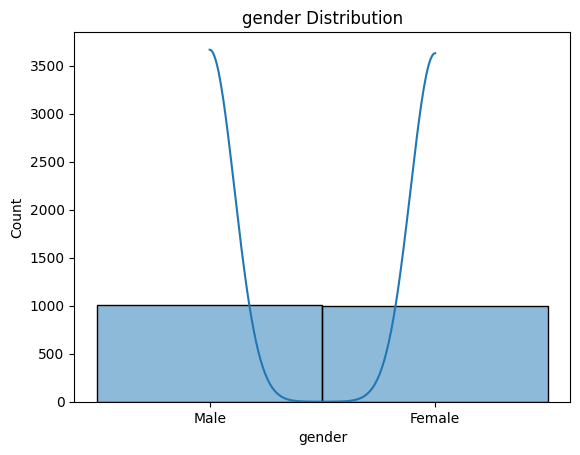

In [ ]:
sns.histplot(data1['gender'],bins=20,kde=True)
plt.title("gender Distribution")
plt.show()

In [ ]:
Numerical_columns = data1.select_dtypes(exclude=['int64','float64']).columns
print(Numerical_columns)

Index(['case_id', 'country', 'region', 'report_date', 'virus_strain',
       'transmission_type', 'exposure_source', 'gender', 'symptoms',
       'hospitalization', 'fatality'],
      dtype='object')


In [ ]:
le = LabelEncoder()

In [ ]:
data1['country'] = le.fit_transform(data1['country'])
data1['region'] = le.fit_transform(data1['region'])
data1['report_date'] = le.fit_transform(data1['report_date'])
data1['virus_strain'] = le.fit_transform(data1['virus_strain'])
data1['transmission_type'] = le.fit_transform(data1['transmission_type'])
data1['exposure_source'] = le.fit_transform(data1['exposure_source'])

In [ ]:
data1

,case_id,country,region,report_date,virus_strain,transmission_type,exposure_source,patient_age,gender,symptoms,hospitalization,fatality,recovery_days,temperature_celsius,humidity_percent,rodent_presence_index,quarantine_days,population_density,air_quality_index
0,HV2026_00001,3,718,320,4,1,0,26,Male,"Headache, Vomiting, Fever",Yes,No,22.0,27.0,78.9,7,1,538,67
1,HV2026_00002,1,271,109,4,0,3,41,Female,"Fever, Muscle Pain, Fatigue",Yes,No,41.0,23.2,70.9,3,13,5624,162
2,HV2026_00003,4,1387,78,3,0,3,39,Female,"Fever, Muscle Pain, Fatigue",No,No,31.0,22.6,38.5,8,17,2095,213
3,HV2026_00004,0,1781,40,4,0,4,49,Male,"Fever, Muscle Pain, Fatigue",No,No,11.0,22.6,87.0,7,8,7478,206
4,HV2026_00005,4,794,82,1,1,3,59,Male,"Fever, Cough, Headache",No,No,24.0,33.5,36.2,8,12,4472,132
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,HV2026_01996,1,1523,367,0,1,3,43,Female,"Shortness of Breath, Fever",No,No,30.0,25.9,71.6,2,2,9022,72
1996,HV2026_01997,2,992,340,2,0,4,52,Female,"Shortness of Breath, Fever",Yes,No,35.0,17.3,50.7,8,14,7014,67
1997,HV2026_01998,5,197,255,1,0,5,64,Female,"Headache, Vomiting, Fever",No,No,24.0,23.8,60.1,3,19,309,210
1998,HV2026_01999,6,1670,355,3,1,3,29,Male,"Shortness of Breath, Fever",No,No,45.0,26.1,52.3,3,7,3843,21


**Objective**

The objective of this model is to use the features country, region, report date, virus strain, transmission type, and exposure source to predict the case ID.

In [ ]:
X = data1[['country', 'region', 'report_date', 'virus_strain',
           'transmission_type', 'exposure_source']]
y = data1['case_id']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
svm = SVC(kernel='rbf')
svm.fit(X_train_scaled, y_train)

In [ ]:
y_pred = svm.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))

The SVM model successfully analyzed the selected features and performed the classification task effectively, demonstrating its capability to identify patterns and make accurate predictions from the dataset.